In [99]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns



### Column Name,Description
country,Name of the country

child_mort,Death of children under 5 years of age per 1000 live births

exports,Exports of goods and services per capita. Given as %age of the GDP per capita

health,Total health spending per capita. Given as %age of GDP per capita

imports,Imports of goods and services per capita. Given as %age of the GDP per capita

Income,Net income per person

Inflation,The measurement of the annual growth rate of the Total GDP

life_expec,The average number of years a new born child would live if the current mortality patterns are to remain the same

total_fer,The number of children that would be born to each woman if the current age-fertility rates remain the same.

gdpp,The GDP per capita. Calculated as the Total GDP divided by the total population.

In [100]:
data=pd.read_csv('Country-data.csv')
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [101]:
data['country'].nunique()

167

In [102]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [103]:
data.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [104]:
data.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [141]:
data.columns

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp', 'Cluster', 'Aid_Status'],
      dtype='str')

In [105]:
data=data.set_index('country')

In [140]:
numerical_col=['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp']

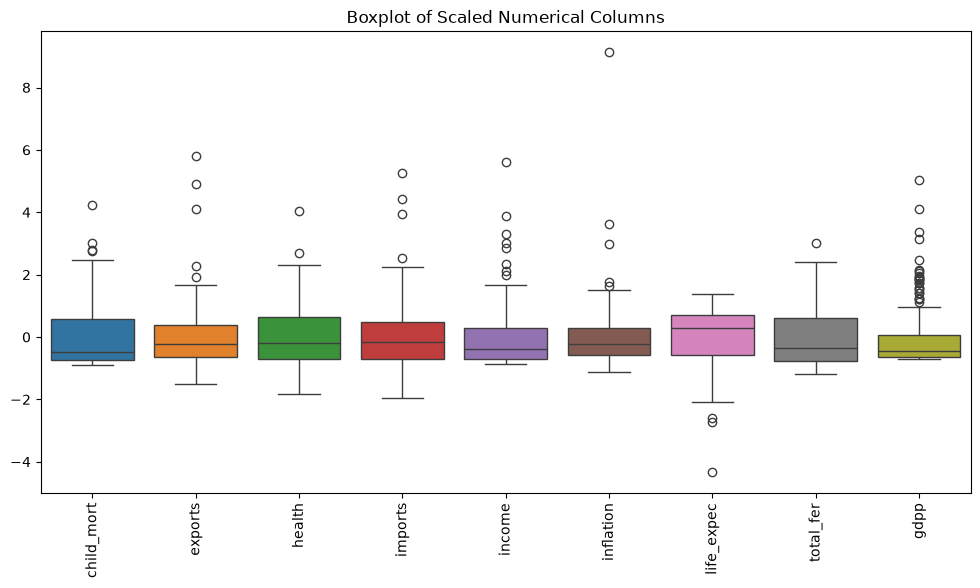

In [142]:
#boxplot 
from sklearn.preprocessing import StandardScaler

scaler_eda=StandardScaler()
scaled_eda=scaler_eda.fit_transform(data[numerical_col])
data_clean_scaled=pd.DataFrame(scaled_eda,columns=numerical_col)

plt.figure(figsize=(12,6))
sns.boxplot(data=data_clean_scaled)
plt.title('Boxplot of Scaled Numerical Columns')
plt.xticks(rotation=90)
plt.show()

In [106]:
data.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [107]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(data)

StandardScaler()

In [108]:
scaled_data=scaler.transform(data)

In [109]:
scaled_data.shape

(167, 9)

In [110]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca.fit(scaled_data)


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [111]:
pca_data=pca.transform(scaled_data)

In [112]:
pca_data.shape

(167, 2)

In [113]:
from sklearn.cluster import KMeans

In [114]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

In [115]:
wcss

[1503.0000000000002,
 1405.9427540286968,
 831.4244352086873,
 759.9590243580755,
 635.7832156283487,
 583.464251173395,
 580.3043395147014,
 510.54778319322907,
 436.94423347884117,
 396.5887954965367]

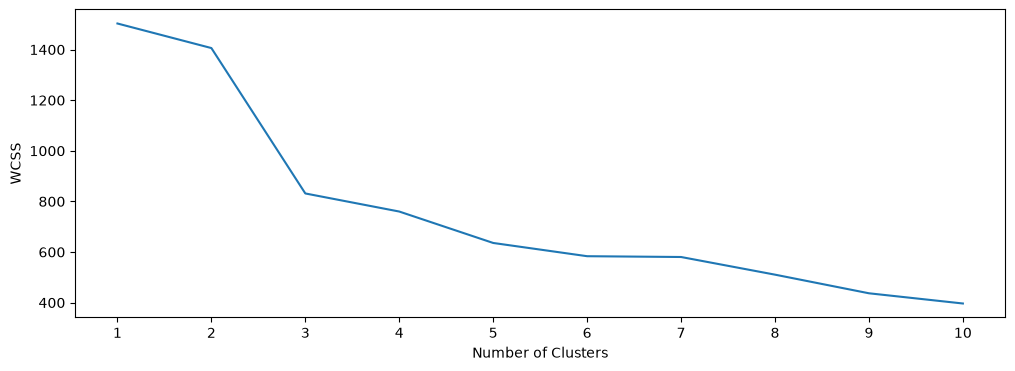

In [116]:
plt.figure(figsize=(12,4))
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [117]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=3,init='k-means++',random_state=42)
labels=model.fit_predict(scaled_data)



In [118]:

pd.Series(labels).value_counts().sort_index()

0    86
1    36
2    45
Name: count, dtype: int64

In [119]:
data["Cluster"] = labels

In [120]:
data[["Cluster"]].head()

,Cluster
country,
Afghanistan,2
Albania,0
Algeria,0
Angola,2
Antigua and Barbuda,0


In [121]:
data.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
country,,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [122]:
cluster_summary = data.groupby("Cluster").mean(numeric_only=True)

cluster_summary[
    ["child_mort", "income", "life_expec", "total_fer", "gdpp"]
]

,child_mort,income,life_expec,total_fer,gdpp
Cluster,,,,,
0,22.456977,12321.744186,72.566279,2.340349,6461.767442
1,5.000000,45672.222222,80.127778,1.752778,42494.444444
2,95.106667,3539.844444,59.055556,5.065333,1766.711111


In [123]:
cluster_names = {
    0: "Might Need Help",
    1: "Help Not Needed ",
    2: "Help Needed"
}

data["Aid_Status"] = data["Cluster"].map(cluster_names)

data[["Cluster", "Aid_Status"]]

,Cluster,Aid_Status
country,,
Afghanistan,2,Help Needed
Albania,0,Might Need Help
Algeria,0,Might Need Help
Angola,2,Help Needed
Antigua and Barbuda,0,Might Need Help
...,...,...
Vanuatu,0,Might Need Help
Venezuela,0,Might Need Help
Vietnam,0,Might Need Help


In [124]:
import plotly.express as px

map_data = data.reset_index()

fig = px.choropleth(
    map_data,
    locations="country",
    locationmode="country names",
    color="Aid_Status",
    hover_name="country",
    title="Country Aid Priority Based on Socio-Economic and Health Indicators",
    color_discrete_map={
        "Might Need Help": "#F9A825",
        "Help Not Needed":"#2E7D32",
        "Help Needed":"#D32F2F"
    }
)

fig.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_1172\2435310305.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [125]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data,labels)

print("Silhouette Score:", score)

Silhouette Score: 0.285600988953231


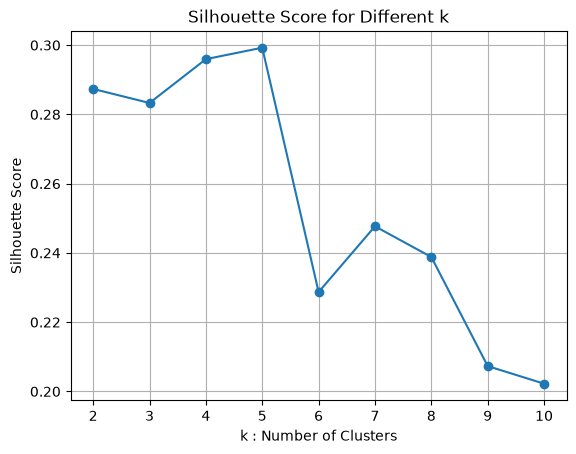

In [126]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("k : Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k")
plt.xticks(range(2, 11))
plt.grid()
plt.show()

In [127]:
for k, score in zip(range(2, 11), silhouette_scores):
    print("k =", k, "Silhouette Score =", score)

k = 2 Silhouette Score = 0.28735668921406704
k = 3 Silhouette Score = 0.28329575683463126
k = 4 Silhouette Score = 0.29595170577528157
k = 5 Silhouette Score = 0.2992594995920442
k = 6 Silhouette Score = 0.22869157246806018
k = 7 Silhouette Score = 0.2476808104838398
k = 8 Silhouette Score = 0.23881101831198853
k = 9 Silhouette Score = 0.20731224410666968
k = 10 Silhouette Score = 0.20223005028962746
